orders: (99441, 8)
items : (112650, 7)

Purchase timestamp range: 2016-09-04 21:15:19 ~ 2018-10-17 17:30:18
Order status distribution:
 order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

After merge: (96478, 11)
Missing revenue: 0
                           order_id order_purchase_timestamp order_status  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33    delivered   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37    delivered   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49    delivered   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06    delivered   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39    delivered   

   total_revenue  
0          38.71  
1         141.46  
2         179.12  
3          72.20  
4          28.62  

Number of days: 612
Range: 2016-09

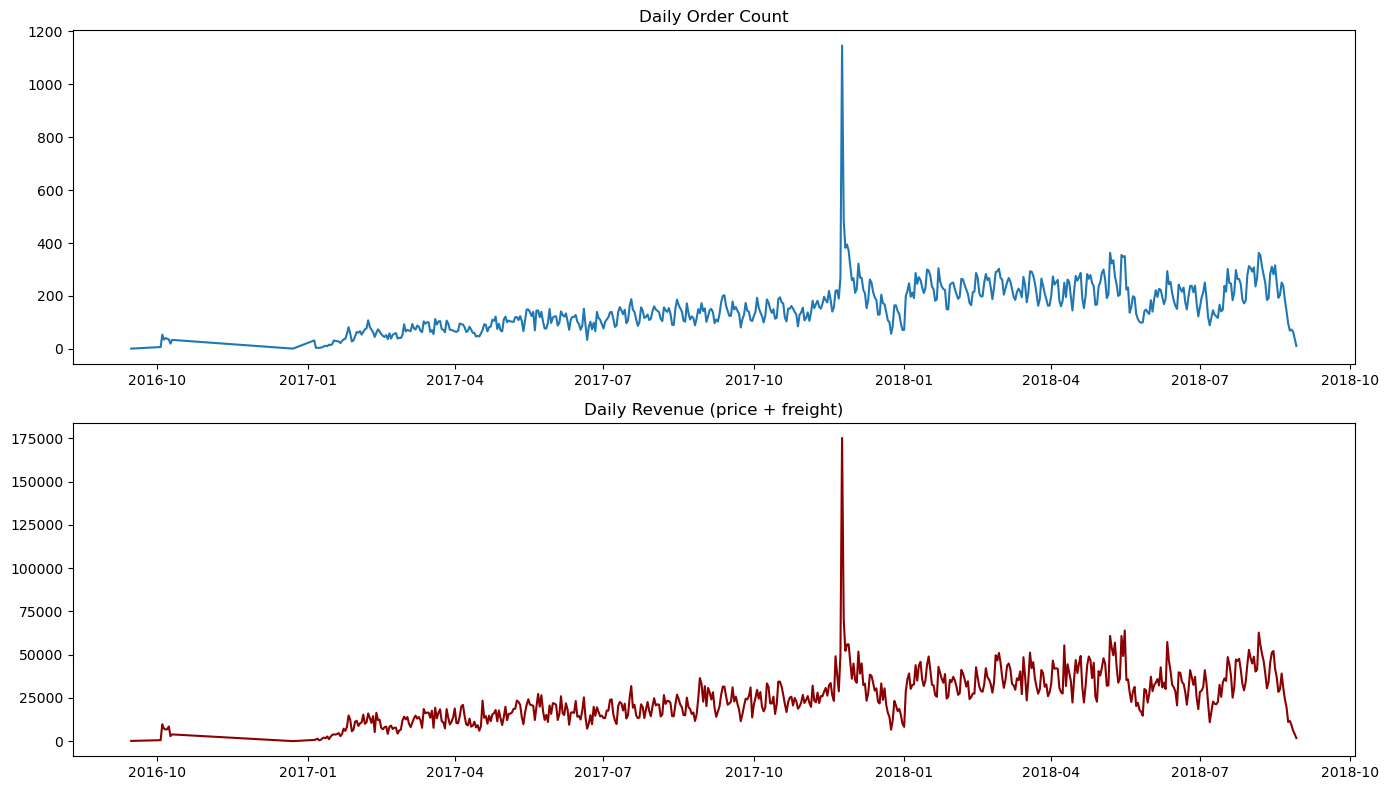

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
# ===== Only this path needs to match your environment =====
PATH = r'C:\Users\Peter\Desktop\Brazilian E-Commerce Public Dataset by Olist'

# =========================================================
# Cell 1 - Libraries & data load
# =========================================================
orders = pd.read_csv(os.path.join(PATH, "olist_orders_dataset.csv"))
items  = pd.read_csv(os.path.join(PATH, "olist_order_items_dataset.csv"))

# convert date columns to datetime
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print("orders:", orders.shape)
print("items :", items.shape)
print("\nPurchase timestamp range:", orders["order_purchase_timestamp"].min(), "~", orders["order_purchase_timestamp"].max())
print("Order status distribution:\n", orders["order_status"].value_counts())


# =========================================================
# Cell 2 - Build order-level revenue
# =========================================================
order_revenue = (
    items.groupby("order_id")
    .agg(revenue=("price", "sum"),
         freight=("freight_value", "sum"))
    .reset_index()
)
order_revenue["total_revenue"] = order_revenue["revenue"] + order_revenue["freight"]

df = orders.merge(order_revenue, on="order_id", how="inner")
df = df[df["order_status"] == "delivered"].copy()   # <- this line added

print("\nAfter merge:", df.shape)
print("Missing revenue:", df["total_revenue"].isna().sum())
print(df[["order_id", "order_purchase_timestamp", "order_status", "total_revenue"]].head())


# =========================================================
# Cell 3 - Daily aggregation
# =========================================================
df["order_date"] = df["order_purchase_timestamp"].dt.date

daily = (
    df.groupby("order_date")
    .agg(order_count=("order_id", "nunique"),
         daily_revenue=("total_revenue", "sum"))
    .reset_index()
)
daily["order_date"] = pd.to_datetime(daily["order_date"])
daily = daily.sort_values("order_date").reset_index(drop=True)

print("\nNumber of days:", len(daily))
print("Range:", daily["order_date"].min(), "~", daily["order_date"].max())
print("\nLast 60 days:")
print(daily.tail(60).to_string())


# =========================================================
# Cell 4 - Monthly aggregation + visualization
# =========================================================
daily["ym"] = daily["order_date"].dt.to_period("M")
monthly = daily.groupby("ym").agg(
    order_count=("order_count", "sum"),
    revenue=("daily_revenue", "sum")
).reset_index()
monthly["ym"] = monthly["ym"].astype(str)

print("\nMonthly aggregation:")
print(monthly.to_string())

fig, ax = plt.subplots(2, 1, figsize=(14, 8))
ax[0].plot(daily["order_date"], daily["order_count"])
ax[0].set_title("Daily Order Count")
ax[1].plot(daily["order_date"], daily["daily_revenue"], color="darkred")
ax[1].set_title("Daily Revenue (price + freight)")
plt.tight_layout()
plt.show()

In [3]:
# =========================================================
# Build daily_full (full date range with missing days filled as 0)
# =========================================================
full_range = pd.date_range(daily["order_date"].min(), daily["order_date"].max(), freq="D")
daily_numeric = daily[["order_date", "order_count", "daily_revenue"]].set_index("order_date")
daily_full = daily_numeric.reindex(full_range, fill_value=0).reset_index()
daily_full.columns = ["order_date", "order_count", "daily_revenue"]

print("daily_full shape:", daily_full.shape)

daily_full shape: (714, 3)


In [4]:
# 1. Check whether (order_id, order_item_id) combos repeat (true duplicate-row check)
dup_check = items.duplicated(subset=["order_id", "order_item_id"], keep=False)
print("Rows suspected fully duplicate:", dup_check.sum())
print(items[dup_check].sort_values(["order_id","order_item_id"]).head(20))

# 2. Check for fully identical rows (all columns match)
full_dup = items.duplicated(keep=False)
print("\nFully duplicate rows (all columns):", full_dup.sum())

# 3. Orders present in orders but missing entirely from items (source of the earlier 99441 vs 98666 gap)
orders_only = set(orders["order_id"]) - set(items["order_id"])
print("\nOrders missing from items:", len(orders_only))
print(orders["order_status"][orders["order_id"].isin(orders_only)].value_counts())

Rows suspected fully duplicate: 0
Empty DataFrame
Columns: [order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value]
Index: []

Fully duplicate rows (all columns): 0

Orders missing from items: 775
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


In [5]:
# compute missing dates
full_range = pd.date_range(daily["order_date"].min(), daily["order_date"].max(), freq="D")
missing_dates = full_range.difference(daily["order_date"])

# missing-day count by month
missing_by_month = pd.Series(missing_dates).dt.to_period("M").value_counts().sort_index()
print("Missing days by month:")
print(missing_by_month)

# check for missing dates inside the reliable window (2017-01 ~ 2018-08-21)
reliable_missing = missing_dates[(missing_dates >= "2017-01-01") & (missing_dates <= "2018-08-21")]
print("\nMissing days within reliable window:", len(reliable_missing))
print(reliable_missing)

Missing days by month:
2016-09    15
2016-10    23
2016-11    30
2016-12    30
2017-01     4
Freq: M, Name: count, dtype: int64

Missing days within reliable window: 4
DatetimeIndex(['2017-01-01', '2017-01-02', '2017-01-03', '2017-01-04'], dtype='datetime64[ns]', freq=None)


In [6]:
# detect where data decay starts by how far the day's value deviates from its 7-day MA -> cutoff set to 2018-08-21
check = daily_full[(daily_full["order_date"] >= "2018-07-01")].copy()
check["ma_7"] = check["order_count"].rolling(7, min_periods=1).mean()
check["ratio_to_ma"] = check["order_count"] / check["ma_7"]

print(check[["order_date","order_count","ma_7","ratio_to_ma"]].to_string())

    order_date  order_count        ma_7  ratio_to_ma
654 2018-07-01          159  159.000000     1.000000
655 2018-07-02          193  176.000000     1.096591
656 2018-07-03          214  188.666667     1.134276
657 2018-07-04          251  204.250000     1.228886
658 2018-07-05          193  202.000000     0.955446
659 2018-07-06          120  188.333333     0.637168
660 2018-07-07           89  174.142857     0.511075
661 2018-07-08          118  168.285714     0.701188
662 2018-07-09          146  161.571429     0.903625
663 2018-07-10          129  149.428571     0.863289
664 2018-07-11          123  131.142857     0.937908
665 2018-07-12          117  120.285714     0.972684
666 2018-07-13          167  127.000000     1.314961
667 2018-07-14          142  134.571429     1.055202
668 2018-07-15          148  138.857143     1.065844
669 2018-07-16          238  152.000000     1.565789
670 2018-07-17          216  164.428571     1.313640
671 2018-07-18          302  190.000000     1.

In [7]:
START_DATE = "2017-01-05"
END_DATE   = "2018-08-21"
check_range = daily_full[
    (daily_full["order_date"] >= START_DATE) &
    (daily_full["order_date"] <= END_DATE)
]
print("Missing days (order_count=0) within window:", (check_range["order_count"] == 0).sum())
print("Total days in window:", len(check_range))

Missing days (order_count=0) within window: 0
Total days in window: 594


# 2017-01-05 to 2018-08-21, 594 days, 0 missing days — the training window is finalized

In [9]:
START_DATE = "2017-01-05"
END_DATE   = "2018-08-21"

model_df = daily_full[
    (daily_full["order_date"] >= START_DATE) &
    (daily_full["order_date"] <= END_DATE)
].copy().reset_index(drop=True)

print("Days used for modeling:", len(model_df))

# ===== calendar features =====
model_df["dayofweek"]  = model_df["order_date"].dt.dayofweek
model_df["month"]      = model_df["order_date"].dt.month
model_df["day"]        = model_df["order_date"].dt.day
model_df["is_weekend"] = model_df["dayofweek"].isin([5, 6]).astype(int)
model_df["day_index"]  = (model_df["order_date"] - model_df["order_date"].min()).dt.days

# ===== Lag / moving-average features (shift(1) prevents same-day leakage) =====
model_df["lag_1"] = model_df["daily_revenue"].shift(1)
model_df["lag_7"] = model_df["daily_revenue"].shift(7)
model_df["ma_7"]  = model_df["daily_revenue"].shift(1).rolling(7).mean()
model_df["ma_30"] = model_df["daily_revenue"].shift(1).rolling(30).mean()

before = len(model_df)
model_df = model_df.dropna().reset_index(drop=True)
print(f"Rows dropped from lag/MA creation: {before - len(model_df)} (the first 30 days of the window)")
print(model_df.shape)
print(model_df.head())
print(model_df.tail())

Days used for modeling: 594
Rows dropped from lag/MA creation: 30 (the first 30 days of the window)
(564, 12)
  order_date  order_count  daily_revenue  dayofweek  month  day  is_weekend  \
0 2017-02-04           64       15320.15          5      2    4           1   
1 2017-02-05           74       10035.21          6      2    5           1   
2 2017-02-06           78       10892.49          0      2    6           0   
3 2017-02-07          108       16004.01          1      2    7           0   
4 2017-02-08           83       13516.29          2      2    8           0   

   day_index     lag_1     lag_7          ma_7        ma_30  
0         30  10797.08   5710.01   9331.275714  5246.740667  
1         31  15320.15   6593.76  10704.152857  5733.836667  
2         32  10035.21  11277.15  11195.788571  6035.401000  
3         33  10892.49  11818.16  11140.837143  6350.217667  
4         34  16004.01   8788.70  11738.815714  6866.756333  
    order_date  order_count  daily_revenue 

In [10]:
import requests
from bs4 import BeautifulSoup
from datetime import date, timedelta
import pandas as pd

# ===== 1. Scrape Brazil's fixed-date holidays with BeautifulSoup =====
def scrape_brazil_fixed_holidays():
    url = "https://en.wikipedia.org/wiki/Public_holidays_in_Brazil"
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(resp.text, "html.parser")

    table = soup.find("table", {"class": "wikitable"})
    rows = table.find_all("tr")[1:]  # skip header row

    month_map = {
        "January":1, "February":2, "March":3, "April":4, "May":5, "June":6,
        "July":7, "August":8, "September":9, "October":10, "November":11, "December":12
    }

    holidays = []
    for row in rows:
        cols = row.find_all("td")
        if len(cols) < 2:
            continue
        date_text = cols[0].get_text(strip=True)   # e.g. "January 1"
        name_en   = cols[1].get_text(strip=True)
        parts = date_text.split()
        if len(parts) != 2:
            continue
        month_name, day = parts[0], parts[1].replace(",", "")
        if month_name not in month_map:
            continue
        # exclude entries that weren't a national holiday as of 2017-2018
        if name_en == "Black Consciousness Day":
            continue
        holidays.append({"month": month_map[month_name], "day": int(day), "name": name_en})

    return pd.DataFrame(holidays)

fixed_holidays = scrape_brazil_fixed_holidays()
print("Scraped fixed-date holidays:")
print(fixed_holidays)

# ===== 2. Compute Easter-based movable holidays (Gauss algorithm) =====
def calc_easter(year):
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19*a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2*e + 2*i - h - k) % 7
    m = (a + 11*h + 22*l) // 451
    month = (h + l - 7*m + 114) // 31
    day = ((h + l - 7*m + 114) % 31) + 1
    return date(year, month, day)

def movable_holidays(year):
    easter = calc_easter(year)
    return {
        "carnival": easter - timedelta(days=47),
        "good_friday": easter - timedelta(days=2),
        "corpus_christi": easter + timedelta(days=60),
    }

# ===== 3. Black Friday = 4th Thursday + 1 =====
def black_friday(year):
    d = date(year, 11, 1)
    thursdays = []
    while d.month == 11:
        if d.weekday() == 3:  # Thursday = 3
            thursdays.append(d)
        d += timedelta(days=1)
    fourth_thursday = thursdays[3]
    return fourth_thursday + timedelta(days=1)

# ===== 4. Build the full set of holiday dates (2017, 2018) =====
holiday_dates = set()
black_friday_dates = set()

for year in [2017, 2018]:
    for _, row in fixed_holidays.iterrows():
        try:
            holiday_dates.add(date(year, row["month"], row["day"]))
        except ValueError:
            continue
    mv = movable_holidays(year)
    holiday_dates.update(mv.values())
    black_friday_dates.add(black_friday(year))

print(f"\nTotal holidays (2017-2018): {len(holiday_dates)}")
print(f"Black Friday dates: {sorted(black_friday_dates)}")

# ===== 5. Merge into model_df =====
model_df["is_holiday"] = model_df["order_date"].dt.date.isin(holiday_dates).astype(int)
model_df["is_black_friday"] = model_df["order_date"].dt.date.isin(black_friday_dates).astype(int)

print("\nDates flagged as holidays:")
print(model_df[model_df["is_holiday"] == 1][["order_date", "daily_revenue"]])
print("\nDates flagged as Black Friday:")
print(model_df[model_df["is_black_friday"] == 1][["order_date", "daily_revenue"]])

print("\nmodel_df shape:", model_df.shape)

Scraped fixed-date holidays:
   month  day                   name
0      1    1         New Year's Day
1      4   21         Tiradentes Day
2      5    1             Labour Day
3      9    7       Independence Day
4     10   12  Our Lady of Aparecida
5     11    2         All Souls' Day
6     11   15           Republic Day
7     12   25          Christmas Day

Total holidays (2017-2018): 22
Black Friday dates: [datetime.date(2017, 11, 24), datetime.date(2018, 11, 23)]

Dates flagged as holidays:
    order_date  daily_revenue
24  2017-02-28       11992.41
69  2017-04-14        7950.88
76  2017-04-21       10048.39
86  2017-05-01       13923.19
131 2017-06-15       14140.56
215 2017-09-07       19096.76
250 2017-10-12       21724.54
271 2017-11-02       23825.63
284 2017-11-15       26278.57
324 2017-12-25       12059.38
331 2018-01-01        8245.67
374 2018-02-13       27425.08
419 2018-03-30       25993.33
441 2018-04-21       22309.62
451 2018-05-01       37911.35
481 2018-05-31     

In [11]:
overlap = model_df[(model_df["is_weekend"]==1) & (model_df["is_holiday"]==1)]
print("Days where weekend and holiday overlap:", len(overlap))
print(overlap[["order_date","daily_revenue"]])

# also check the correlation
print("\nis_weekend vs is_holiday correlation:", model_df["is_weekend"].corr(model_df["is_holiday"]))

Days where weekend and holiday overlap: 1
    order_date  daily_revenue
441 2018-04-21       22309.62

is_weekend vs is_holiday correlation: -0.08486862114460801


In [12]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ===== define features/target =====
feature_cols = ["dayofweek", "month", "day", "is_weekend", "day_index",
                 "lag_1", "lag_7", "ma_7", "ma_30",
                 "is_holiday", "is_black_friday"]

X = model_df[feature_cols]
y = model_df["daily_revenue"]

# ===== chronological train/test split (first 80% train, last 20% test) =====
split_idx = int(len(model_df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

train_dates = model_df["order_date"].iloc[:split_idx]
test_dates  = model_df["order_date"].iloc[split_idx:]

print("Training period:", train_dates.min(), "~", train_dates.max())
print("Test period:", test_dates.min(), "~", test_dates.max())
print("Training samples:", len(X_train), "Test samples:", len(X_test))

# ===== scaling (for linear models) =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ===== model training + evaluation function =====
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    print(f"[{name}] RMSE={rmse:,.0f}  MAE={mae:,.0f}  R2={r2:.3f}")
    return model, pred

results = {}

# linear-regression family (uses scaled data)
results["LinearRegression"] = evaluate_model("LinearRegression", LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)
results["Ridge"]            = evaluate_model("Ridge",            Ridge(alpha=1.0),   X_train_scaled, X_test_scaled, y_train, y_test)
results["Lasso"]             = evaluate_model("Lasso",            Lasso(alpha=1.0),   X_train_scaled, X_test_scaled, y_train, y_test)

# tree-based (no scaling needed, uses raw X)
results["RandomForest"] = evaluate_model("RandomForest", RandomForestRegressor(n_estimators=200, random_state=42), X_train, X_test, y_train, y_test)

Training period: 2017-02-04 00:00:00 ~ 2018-04-30 00:00:00
Test period: 2018-05-01 00:00:00 ~ 2018-08-21 00:00:00
Training samples: 451 Test samples: 113
[LinearRegression] RMSE=8,550  MAE=7,051  R2=0.397
[Ridge] RMSE=8,481  MAE=6,976  R2=0.407
[Lasso] RMSE=8,543  MAE=7,044  R2=0.398
[RandomForest] RMSE=7,647  MAE=5,966  R2=0.518


            feature  importance
7              ma_7    0.482712
10  is_black_friday    0.211816
5             lag_1    0.095808
4         day_index    0.062580
0         dayofweek    0.054761
6             lag_7    0.034514
8             ma_30    0.023185
2               day    0.017889
1             month    0.008130
3        is_weekend    0.007016
9        is_holiday    0.001588


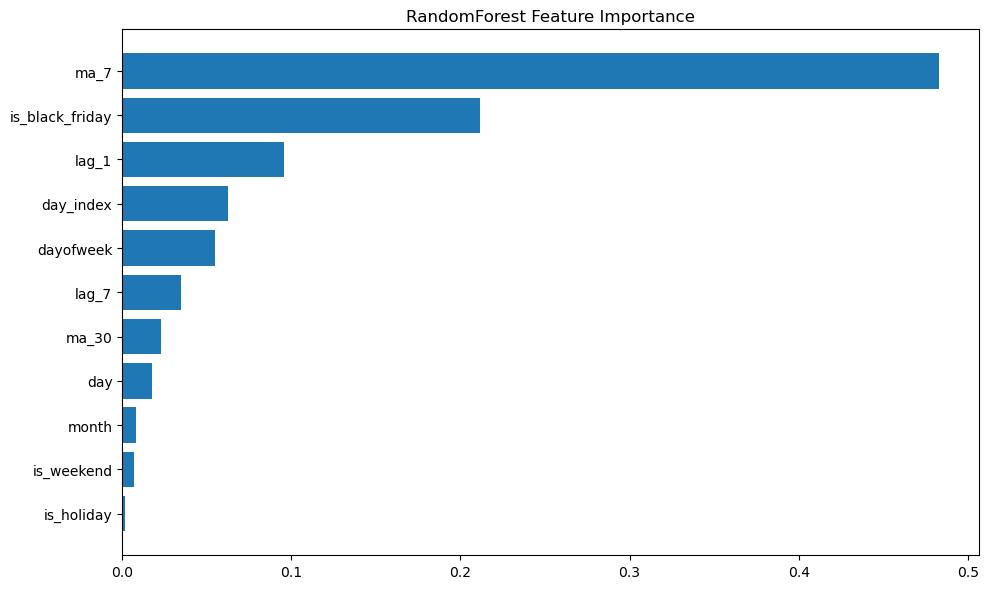

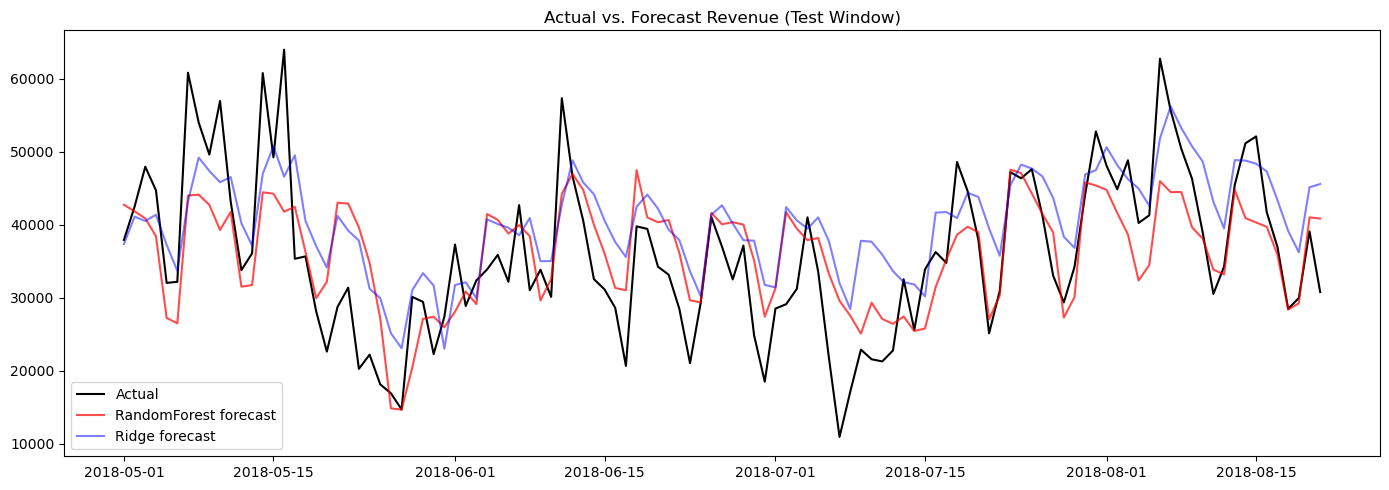

In [13]:
# ===== feature importance (RandomForest) =====
rf_model, rf_pred = results["RandomForest"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.to_string())

plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.title("RandomForest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ===== predicted vs. actual (test window) =====
plt.figure(figsize=(14,5))
plt.plot(test_dates, y_test.values, label="Actual", color="black")
plt.plot(test_dates, rf_pred, label="RandomForest forecast", color="red", alpha=0.7)
plt.plot(test_dates, results["Ridge"][1], label="Ridge forecast", color="blue", alpha=0.5)
plt.legend()
plt.title("Actual vs. Forecast Revenue (Test Window)")
plt.tight_layout()
plt.show()

# (Additional analysis) checking statistical significance of the features

In [15]:
# ===== scipy statistical tests =====
from scipy import stats

# (a) Black Friday vs. normal-day revenue comparison (independent-samples t-test); Black Friday is a single day, so a z-score is used instead of the t-test below
bf_revenue = model_df[model_df["is_black_friday"] == 1]["daily_revenue"]
normal_revenue = model_df[(model_df["is_black_friday"] == 0) & (model_df["is_holiday"] == 0)]["daily_revenue"]

t_stat, p_value = stats.ttest_ind(bf_revenue, normal_revenue, equal_var=False)
print("=== Black Friday vs. normal day ===")
print(f"Black Friday mean: {bf_revenue.mean():,.0f}  (n={len(bf_revenue)})")
print(f"Normal-day mean: {normal_revenue.mean():,.0f}  (n={len(normal_revenue)})")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.5f}")
print("-> statistically significant" if p_value < 0.05 else "-> not statistically significant")

# (b) Weekend vs. weekday revenue comparison
weekend_revenue = model_df[model_df["is_weekend"] == 1]["daily_revenue"]
weekday_revenue = model_df[model_df["is_weekend"] == 0]["daily_revenue"]

t_stat2, p_value2 = stats.ttest_ind(weekend_revenue, weekday_revenue, equal_var=False)
print("\n=== Weekend vs. weekday ===")
print(f"Weekend mean: {weekend_revenue.mean():,.0f}  (n={len(weekend_revenue)})")
print(f"Weekday mean: {weekday_revenue.mean():,.0f}  (n={len(weekday_revenue)})")
print(f"t-statistic: {t_stat2:.3f}, p-value: {p_value2:.5f}")
print("-> statistically significant" if p_value2 < 0.05 else "-> not statistically significant")

# (c) Holiday vs. normal-day revenue comparison
holiday_revenue = model_df[(model_df["is_holiday"] == 1)]["daily_revenue"]

t_stat3, p_value3 = stats.ttest_ind(holiday_revenue, normal_revenue, equal_var=False)
print("\n=== Holiday vs. normal day ===")
print(f"Holiday mean: {holiday_revenue.mean():,.0f}  (n={len(holiday_revenue)})")
print(f"Normal-day mean: {normal_revenue.mean():,.0f}  (n={len(normal_revenue)})")
print(f"t-statistic: {t_stat3:.3f}, p-value: {p_value3:.5f}")
print("-> statistically significant" if p_value3 < 0.05 else "-> not statistically significant")

=== Black Friday vs. normal day ===
Black Friday mean: 175,178  (n=1)
Normal-day mean: 26,768  (n=547)
t-statistic: nan, p-value: nan
-> not statistically significant

=== Weekend vs. weekday ===
Weekend mean: 21,333  (n=162)
Weekday mean: 29,034  (n=402)
t-statistic: -7.258, p-value: 0.00000
-> statistically significant

=== Holiday vs. normal day ===
Holiday mean: 19,394  (n=16)
Normal-day mean: 26,768  (n=547)
t-statistic: -3.340, p-value: 0.00392
-> statistically significant


C:\Users\Peter\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
C:\Users\Peter\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


In [16]:
bf_value = model_df[model_df["is_black_friday"] == 1]["daily_revenue"].values[0]

z_score = (bf_value - normal_revenue.mean()) / normal_revenue.std()
percentile = stats.percentileofscore(normal_revenue, bf_value)

print(f"Black Friday revenue: {bf_value:,.0f}")
print(f"Normal-day mean: {normal_revenue.mean():,.0f}, std dev: {normal_revenue.std():,.0f}")
print(f"z-score: {z_score:.2f}  ({z_score:.1f} standard deviations above the normal-day mean)")
print(f"Percentile: {percentile:.1f}%  (share of {len(normal_revenue)} normal days below this value)")

Black Friday revenue: 175,178
Normal-day mean: 26,768, std dev: 12,248
z-score: 12.12  (12.1 standard deviations above the normal-day mean)
Percentile: 100.0%  (share of 547 normal days below this value)


In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = model_df[feature_cols].copy()
vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_df.sort_values("VIF", ascending=False).to_string())

            feature        VIF
7              ma_7  56.502669
8             ma_30  54.730227
4         day_index  24.050173
6             lag_7  17.870855
5             lag_1  15.320772
0         dayofweek   7.625696
1             month   4.356333
3        is_weekend   4.099780
2               day   3.391568
9        is_holiday   1.046352
10  is_black_friday   1.016762


# Checking revenue before and after Black Friday

In [19]:
nov_2017 = daily_full[
    (daily_full["order_date"] >= "2017-11-15") &
    (daily_full["order_date"] <= "2017-11-30")
].copy()

# also show the multiple vs. the normal-day average for easy comparison
normal_avg = normal_revenue.mean()
nov_2017["ratio_to_normal"] = nov_2017["daily_revenue"] / normal_avg

print(nov_2017[["order_date","order_count","daily_revenue","ratio_to_normal"]].to_string())

    order_date  order_count  daily_revenue  ratio_to_normal
426 2017-11-15          176       26278.57         0.981700
427 2017-11-16          219       32236.16         1.204260
428 2017-11-17          185       33589.38         1.254813
429 2017-11-18          141       26543.38         0.991592
430 2017-11-19          157       23273.60         0.869442
431 2017-11-20          219       49072.99         1.833240
432 2017-11-21          222       38506.59         1.438507
433 2017-11-22          190       28780.67         1.075172
434 2017-11-23          268       49748.15         1.858462
435 2017-11-24         1147      175178.46         6.544215
436 2017-11-25          487       70683.26         2.640544
437 2017-11-26          382       52162.53         1.948657
438 2017-11-27          395       55887.39         2.087809
439 2017-11-28          372       55990.30         2.091653
440 2017-11-29          314       46164.91         1.724602
441 2017-11-30          260       36079.

# (Final model) added daily unique-customer and seller-count features -> improved performance

In [21]:
# build daily unique customer / seller counts (df needs customer_id; seller_id comes from items - merge with orders to get customer_id)
daily_entities = df.groupby("order_date").agg(
    n_customers=("customer_id", "nunique")
).reset_index()
daily_entities["order_date"] = pd.to_datetime(daily_entities["order_date"])

# seller_id lives in the items table, so it needs a separate merge
seller_daily = items.merge(df[["order_id","order_date"]], on="order_id", how="inner")
seller_daily = seller_daily.groupby("order_date")["seller_id"].nunique().reset_index()
seller_daily.columns = ["order_date", "n_sellers"]
seller_daily["order_date"] = pd.to_datetime(seller_daily["order_date"])

# merge into daily_full
daily_full_v2 = daily_full.merge(daily_entities, on="order_date", how="left").merge(seller_daily, on="order_date", how="left")
daily_full_v2[["n_customers","n_sellers"]] = daily_full_v2[["n_customers","n_sellers"]].fillna(0)

# attach to model_df and add the lag
model_df_v7 = model_df.merge(daily_full_v2[["order_date","n_customers","n_sellers"]], on="order_date", how="left")
model_df_v7["lag_customers_1"] = model_df_v7["n_customers"].shift(1)
model_df_v7["lag_sellers_1"] = model_df_v7["n_sellers"].shift(1)
model_df_v7 = model_df_v7.dropna(subset=["lag_customers_1","lag_sellers_1"])

feature_cols_v7 = feature_cols + ["lag_customers_1", "lag_sellers_1"]

X7 = model_df_v7[feature_cols_v7]
y7 = model_df_v7["daily_revenue"]
split7 = int(len(model_df_v7) * 0.8)
X7_train, X7_test = X7.iloc[:split7], X7.iloc[split7:]
y7_train, y7_test = y7.iloc[:split7], y7.iloc[split7:]

rf_v7 = RandomForestRegressor(n_estimators=200, random_state=42)
_, pred_v7 = evaluate_model("RandomForest (+ customer/seller counts)", rf_v7, X7_train, X7_test, y7_train, y7_test)

[RandomForest (+ customer/seller counts)] RMSE=7,226  MAE=5,702  R2=0.569


In [22]:
rf_v7_model, _ = None, None  # already trained as rf_v7 above, reused here
importance_v7 = pd.DataFrame({
    "feature": feature_cols_v7,
    "importance": rf_v7.feature_importances_
}).sort_values("importance", ascending=False)
print(importance_v7.to_string())

            feature  importance
7              ma_7    0.230242
12    lag_sellers_1    0.216847
10  is_black_friday    0.208847
11  lag_customers_1    0.132483
0         dayofweek    0.046477
6             lag_7    0.043471
4         day_index    0.041292
5             lag_1    0.040095
8             ma_30    0.016121
2               day    0.013937
1             month    0.005534
3        is_weekend    0.003701
9        is_holiday    0.000953


Test window: 2018-05-01 00:00:00 ~ 2018-08-21 00:00:00
              actual     forecast        diff
order_date                                   
2018-05-01  37911.35  41637.27915  3725.92915
2018-05-02  42472.00  41623.50435   848.49565
2018-05-03  47935.10  41077.63690  6857.46310
2018-05-04  44708.27  38837.60005  5870.66995
2018-05-05  32029.90  30516.49285  1513.40715


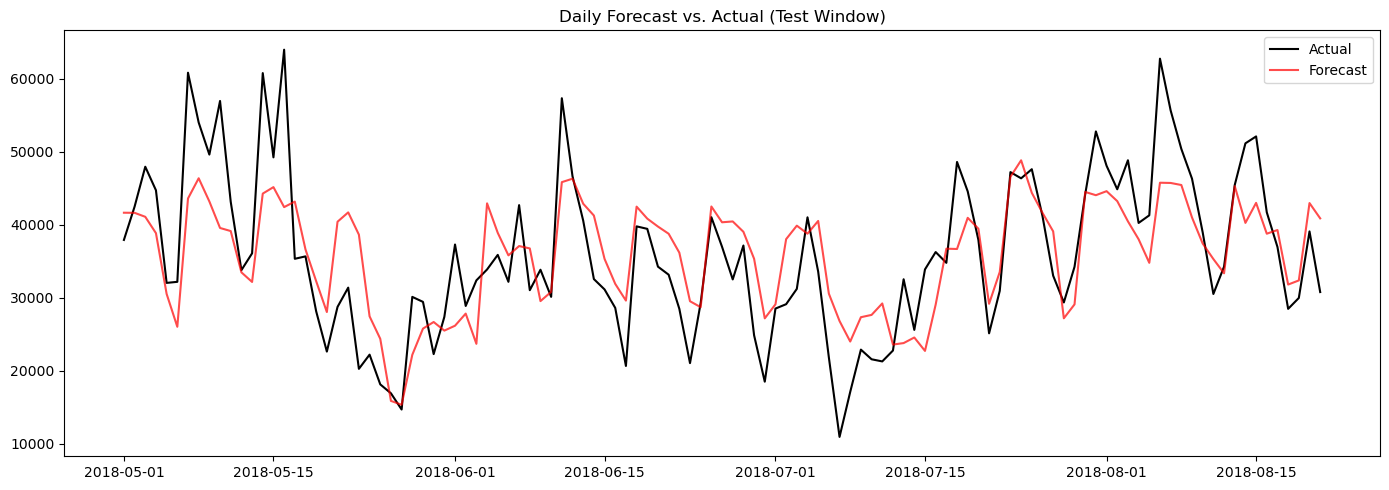


=== Weekly aggregate comparison ===
               actual      forecast         diff  error_rate_pct
order_date                                                      
2018-04-30  237231.51  219712.73720  24970.63110           10.53
2018-05-07  334320.97  277431.80925  56889.16075           17.02
2018-05-14  295684.01  271879.50700  60449.06360           20.44
2018-05-21  152339.97  203771.38930  53514.18790           35.13
2018-05-28  207727.20  177806.92365  38712.40065           18.64
2018-06-04  239565.48  251765.00270  31991.90010           13.35
2018-06-11  257453.53  273058.83560  39254.98010           15.25
2018-06-18  225421.29  256190.04390  31946.25450           14.17
2018-06-25  219521.24  253890.16470  34368.92470           15.66
2018-07-02  184784.27  238528.34765  58231.21105           31.51
2018-07-09  180512.24  178843.62130  40207.54680           22.27
2018-07-16  258143.04  245526.02490  32840.51650           12.72
2018-07-23  278921.17  276711.27890  20165.73970     

In [23]:
# ===== 1. Assemble test-window forecasts alongside their dates =====
test_dates_v7 = model_df_v7["order_date"].iloc[split7:].reset_index(drop=True)
actual_v7 = y7_test.reset_index(drop=True)
pred_v7_series = pd.Series(pred_v7).reset_index(drop=True)

daily_result = pd.DataFrame({
    "order_date": test_dates_v7,
    "actual": actual_v7,
    "forecast": pred_v7_series
})
daily_result["diff"] = abs(daily_result["actual"] - daily_result["forecast"])
daily_result = daily_result.set_index("order_date")

print("Test window:", daily_result.index.min(), "~", daily_result.index.max())
print(daily_result.head())

# ===== 2. Daily forecast chart (same format as the reference notebook) =====
plt.figure(figsize=(14,5))
plt.plot(daily_result.index, daily_result["actual"], label="Actual", color="black")
plt.plot(daily_result.index, daily_result["forecast"], label="Forecast", color="red", alpha=0.7)
plt.title("Daily Forecast vs. Actual (Test Window)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== 3. Weekly/monthly aggregate comparison =====
weekly_agg = daily_result.resample("W-MON", label="left", closed="left").sum()
monthly_agg = daily_result.resample("MS").sum()

weekly_agg["error_rate_pct"] = round(weekly_agg["diff"] / weekly_agg["actual"] * 100, 2)
monthly_agg["error_rate_pct"] = round(monthly_agg["diff"] / monthly_agg["actual"] * 100, 2)

print("\n=== Weekly aggregate comparison ===")
print(weekly_agg[["actual","forecast","diff","error_rate_pct"]].to_string())

print("\n=== Monthly aggregate comparison ===")
print(monthly_agg[["actual","forecast","diff","error_rate_pct"]].to_string())

# ===== 4. Total test-period comparison (same format as the reference notebook's diff_df) =====
summary_df = pd.DataFrame(index=["Daily avg", "Weekly avg", "Monthly avg"])
summary_df["avg_error_rate_pct"] = [
    round((daily_result["diff"] / daily_result["actual"]).mean() * 100, 2),
    round(weekly_agg["error_rate_pct"].mean(), 2),
    round(monthly_agg["error_rate_pct"].mean(), 2)
]
print("\n=== Average error rate by aggregation level ===")
print(summary_df)

# Checking figures by region and category

In [25]:
# load products data (not loaded yet)
products = pd.read_csv(os.path.join(PATH, "olist_products_dataset.csv"))

# ===== check average daily transaction volume by category =====
items_cat = items.merge(df[["order_id","order_date"]], on="order_id", how="inner")
items_cat = items_cat.merge(products[["product_id","product_category_name"]], on="product_id", how="left")

total_days = len(daily_full[(daily_full["order_date"]>=START_DATE)&(daily_full["order_date"]<=END_DATE)])
cat_daily_avg = items_cat.groupby("product_category_name").size() / total_days

print("Average daily transactions by category (top 15):")
print(cat_daily_avg.sort_values(ascending=False).head(15))
print("\nBottom 15 (risk of insufficient sample size):")
print(cat_daily_avg.sort_values(ascending=False).tail(15))

# ===== check average daily transaction volume by region (state) =====
customers = pd.read_csv(os.path.join(PATH, "olist_customers_dataset.csv"))
df_state = df.merge(customers[["customer_id","customer_state"]], on="customer_id", how="left")
state_daily_avg = df_state.groupby("customer_state").size() / total_days

print("\nAverage daily transactions by region:")
print(state_daily_avg.sort_values(ascending=False))

Average daily transactions by category (top 15):
product_category_name
cama_mesa_banho           18.439394
beleza_saude              15.934343
esporte_lazer             14.193603
moveis_decoracao          13.737374
informatica_acessorios    12.868687
utilidades_domesticas     11.439394
relogios_presentes         9.863636
telefonia                  7.457912
ferramentas_jardim         7.185185
automotivo                 6.969697
brinquedos                 6.784512
cool_stuff                 6.259259
perfumaria                 5.622896
bebes                      5.020202
eletronicos                4.594276
dtype: float64

Bottom 15 (risk of insufficient sample size):
product_category_name
fashion_roupa_feminina                           0.075758
artigos_de_festas                                0.070707
musica                                           0.063973
moveis_colchao_e_estofado                        0.062290
fraldas_higiene                                  0.062290
flores         

In [26]:
# check cumulative category share
cat_total = items_cat.groupby("product_category_name").size().sort_values(ascending=False)
cat_cumshare = (cat_total.cumsum() / cat_total.sum() * 100).round(1)
print("Cumulative category share (top 10):")
print(cat_cumshare.head(10))

# check cumulative regional share
state_total = df_state.groupby("customer_state").size().sort_values(ascending=False)
state_cumshare = (state_total.cumsum() / state_total.sum() * 100).round(1)
print("\nCumulative regional share:")
print(state_cumshare)

Cumulative category share (top 10):
product_category_name
cama_mesa_banho           10.1
beleza_saude              18.8
esporte_lazer             26.5
moveis_decoracao          34.1
informatica_acessorios    41.1
utilidades_domesticas     47.3
relogios_presentes        52.7
telefonia                 56.8
ferramentas_jardim        60.7
automotivo                64.6
dtype: float64

Cumulative regional share:
customer_state
SP     42.0
RJ     54.8
MG     66.5
RS     72.1
PR     77.2
SC     80.9
BA     84.2
DF     86.4
ES     88.5
GO     90.5
PE     92.1
CE     93.5
PA     94.5
MT     95.4
MA     96.1
MS     96.8
PB     97.4
PI     97.9
RN     98.4
AL     98.8
SE     99.1
TO     99.4
RO     99.7
AM     99.8
AC     99.9
AP    100.0
RR    100.0
dtype: float64


In [ ]:
'''# ===== Dashboard export (feature importance + predicted vs. actual) =====
DASH = r'C:\Users\Peter\Desktop\olist_dashboard\data\sales'
import os; os.makedirs(DASH, exist_ok=True)

importance_v7.to_csv(f'{DASH}/feature_importance.csv', index=False, encoding='utf-8-sig')

pd.DataFrame({
    'order_date': model_df_v7['order_date'].iloc[split7:].values,
    'actual': y7_test.values,
    'forecast': pred_v7,
}).to_csv(f'{DASH}/pred_vs_actual.csv', index=False, encoding='utf-8-sig')

print('Daily model export done')'''

In [ ]:
'''# ===== Dashboard export (calendar effects) =====
DASH = r'C:\Users\Peter\Desktop\olist_dashboard\data\sales'
import os; os.makedirs(DASH, exist_ok=True)

weekend_rev = model_df[model_df['is_weekend'] == 1]['daily_revenue']
weekday_rev = model_df[model_df['is_weekend'] == 0]['daily_revenue']
holiday_rev = model_df[model_df['is_holiday'] == 1]['daily_revenue']
normal_rev  = model_df[(model_df['is_holiday'] == 0) & (model_df['is_black_friday'] == 0)]['daily_revenue']
bf_rev      = model_df[model_df['is_black_friday'] == 1]['daily_revenue']

calendar_effect = pd.DataFrame([
    {'label': 'Weekday', 'revenue': weekday_rev.mean(), 'group': 'Day of week'},
    {'label': 'Weekend', 'revenue': weekend_rev.mean(), 'group': 'Day of week'},
    {'label': 'Normal', 'revenue': normal_rev.mean(), 'group': 'Holiday'},
    {'label': 'Holiday', 'revenue': holiday_rev.mean(), 'group': 'Holiday'},
])
calendar_effect.to_csv(f'{DASH}/calendar_effect.csv', index=False, encoding='utf-8-sig')

bf_multiple = bf_rev.mean() / normal_rev.mean()
pd.DataFrame([{'normal_revenue': normal_rev.mean(), 'black_friday_revenue': bf_rev.mean(), 'multiplier': bf_multiple}]).to_csv(
    f'{DASH}/black_friday_effect.csv', index=False, encoding='utf-8-sig')

print(f'Calendar-effect export done (Black Friday {bf_multiple:.2f}x)')'''